In [1]:
import sys
!{sys.executable} -m pip install causationentropy

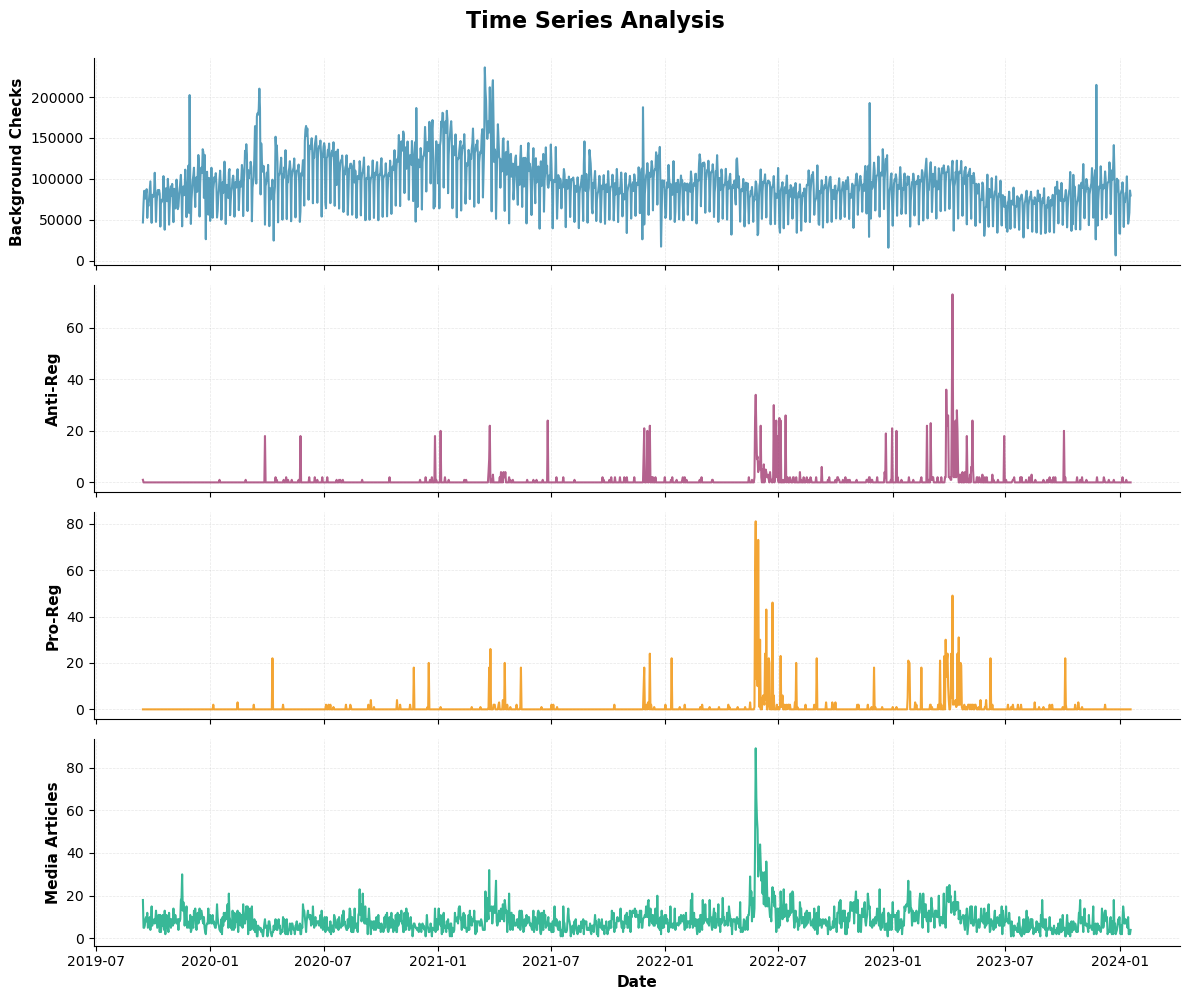

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from causationentropy.core import discover_network

# Load data
df = pd.read_csv("data/all_dailies_reg.csv")
proquest_df = pd.read_csv("data/proquest.csv")

# Count articles per day
proquest_df['PubDate'] = pd.to_datetime(proquest_df['PubDate'])
articles_per_day = proquest_df.groupby('PubDate').size().reset_index(name='Media Articles')

# Prepare main dataframe
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Merge datasets
merged = pd.merge(
    df, 
    articles_per_day, 
    left_on='timestamp', 
    right_on='PubDate', 
    how='inner'
).drop(columns=['PubDate'])

# Rename columns for clarity
merged = merged.rename(columns={
    'bg_checks': 'Background Checks',
    'anti_reg': 'Anti-Reg',
    'pro_reg': 'Pro-Reg'
})

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Time Series Analysis', fontsize=16, fontweight='bold', y=0.995)

# Define colors
colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
variables = ['Background Checks', 'Anti-Reg', 'Pro-Reg', 'Media Articles']

# Plot each variable
for ax, var, color in zip(axes, variables, colors):
    ax.plot(merged['timestamp'], merged[var], color=color, linewidth=1.5, alpha=0.8)
    ax.set_ylabel(var, fontsize=11, fontweight='600')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Set x-axis label only on bottom plot
axes[-1].set_xlabel('Date', fontsize=11, fontweight='600')

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# --- Load ---
df = pd.read_csv("data/all_dailies_reg.csv")
proquest_df = pd.read_csv("data/proquest.csv")

# --- Normalize to date-only keys (avoid time-of-day mismatches) ---
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.floor("D")

proquest_df["PubDate"] = pd.to_datetime(proquest_df["PubDate"])
proquest_df["date"] = proquest_df["PubDate"].dt.floor("D")

# --- Count articles per day ---
articles_per_day = (
    proquest_df.groupby("date").size().reset_index(name="Media Articles")
)

# --- Merge: keep ALL background-check rows (left join), fill missing media with 0 ---
merged = (
    df.merge(articles_per_day, on="date", how="left")
      .drop(columns=["PubDate"], errors="ignore")
      .rename(columns={
          "bg_checks": "Background Checks",
          "anti_reg": "Anti-Reg",
          "pro_reg": "Pro-Reg"
      })
)

merged["Media Articles"] = merged["Media Articles"].fillna(0)


print("Missing Background Checks after left-merge:", merged["Background Checks"].isna().sum())
if merged["Background Checks"].isna().any():
    # If this prints >0, the source CSV itself has gaps for those dates
    print(merged.loc[merged["Background Checks"].isna(), ["date", "Background Checks"]].head(20))


merged = merged.set_index("date").sort_index()
merged = merged.asfreq("D")  # align to daily; should NOT produce NaNs in Background Checks now

result = seasonal_decompose(merged["Background Checks"], model="additive", period=365)
merged["Deseasonalized Background Checks"] = result.observed - result.seasonal

Missing Background Checks after left-merge: 0


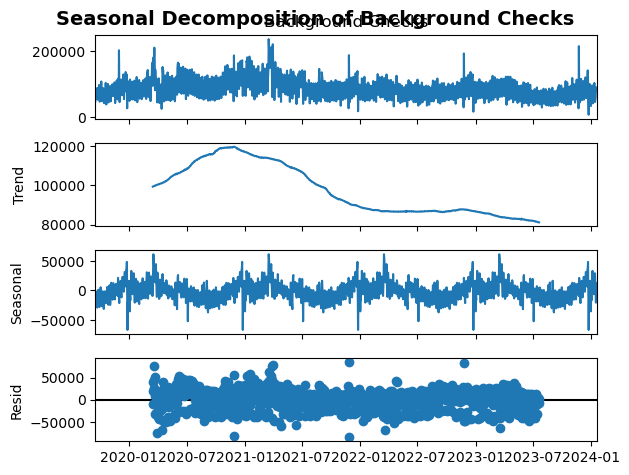

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure timestamp is the index
merged = merged.set_index("timestamp").asfreq("D")  # daily frequency

# Classical seasonal decomposition (additive model is typical for counts)
result = seasonal_decompose(merged["Background Checks"], model="additive", period=365)

# Deseasonalized series = observed - seasonal
merged["Background Checks_deseasonalized"] = result.observed - result.seasonal

# Plot decomposition
result.plot()
plt.suptitle("Seasonal Decomposition of Background Checks", fontsize=14, fontweight='bold')
plt.show()

In [5]:
merged.head()

,Background Checks,Anti-Reg,Pro-Reg,Media Articles,Deseasonalized Background Checks,Background Checks_deseasonalized
timestamp,,,,,,
2019-09-15,46741,1,0,18.0,58848.885371,58848.885371
2019-09-16,69574,0,0,5.0,78874.446102,78874.446102
2019-09-17,85434,0,0,5.0,87451.331033,87451.331033
2019-09-18,83936,0,0,6.0,85801.708202,85801.708202
2019-09-19,75939,0,0,9.0,89730.671673,89730.671673


In [6]:
from causationentropy.core import discover_network
from sklearn.preprocessing import StandardScaler
import numpy as np

data = merged[["Deseasonalized Background Checks", 'Anti-Reg', 'Pro-Reg', 'Media Articles']]

scaler = StandardScaler()
data = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns,
    index=data.index
)

network = discover_network(
    data,
    information='gaussian',
    max_lag=7,              # Maximum time lag to consider
    alpha_forward=0.005,     # Forward selection significance
    alpha_backward=0.005,    # Backward elimination significance
    n_shuffles=200          # Permutation test iterations
)

Estimating edges for node 0 (Deseasonalized Background Checks)


/home/kslote/anaconda3/lib/python3.11/site-packages/causationentropy/core/information/conditional_mutual_information.py:80: RuntimeWarning: invalid value encountered in scalar subtract
  cmi = 0.5 * (SXZ + SYZ - SZ - SXYZ)


Estimating edges for node 1 (Anti-Reg)
Estimating edges for node 2 (Pro-Reg)
Estimating edges for node 3 (Media Articles)


In [7]:
data.corr()

,Deseasonalized Background Checks,Anti-Reg,Pro-Reg,Media Articles
Deseasonalized Background Checks,1.000000,-0.022541,-0.039989,-0.166451
Anti-Reg,-0.022541,1.000000,0.405579,0.304690
Pro-Reg,-0.039989,0.405579,1.000000,0.427082
Media Articles,-0.166451,0.304690,0.427082,1.000000


/tmp/ipykernel_414371/3156852958.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(cmis / max_cmi)
/tmp/ipykernel_414371/3156852958.py:67: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(
/tmp/ipykernel_414371/3156852958.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(normalized_cmis)
/tmp/ipykernel_414371/3156852958.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated 

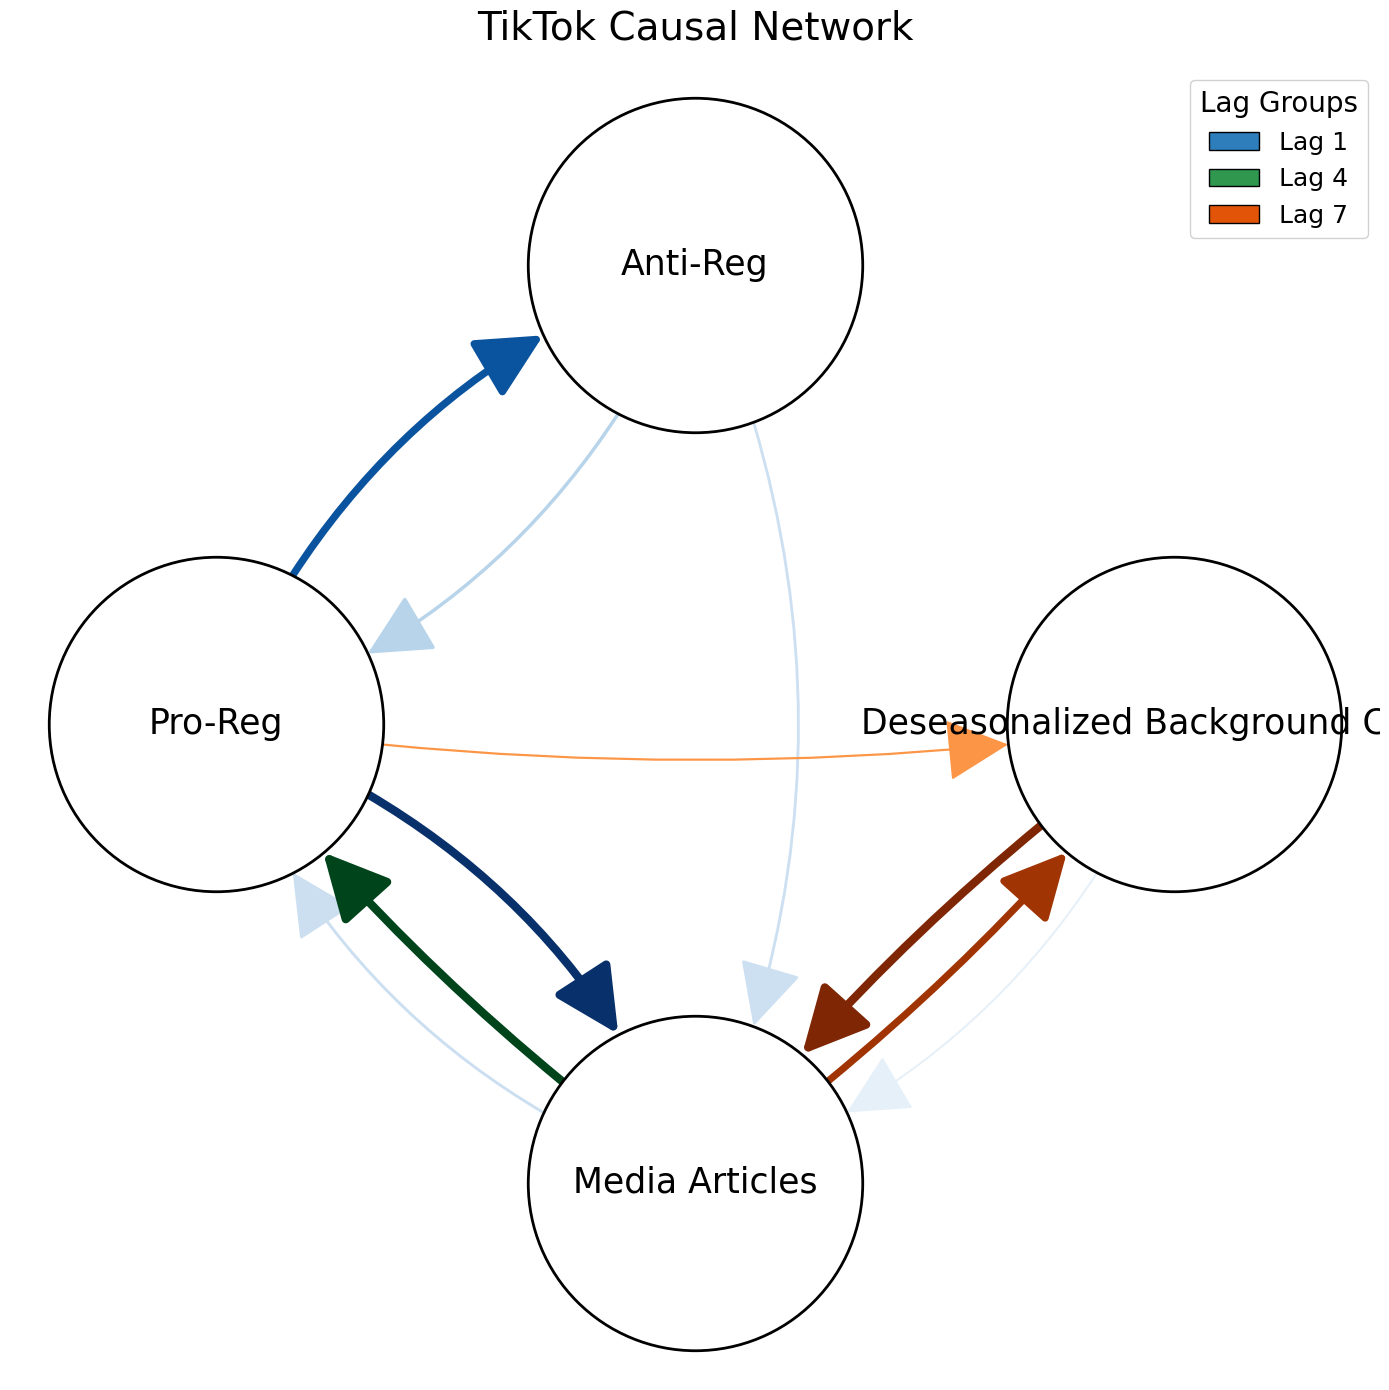

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from collections import defaultdict
from matplotlib.patches import Patch

# Configuration
CONFIG = {
    'node_size': 58000,
    'arrowsize': 100,
    'label_fontsize': 25,
    'figsize': (14, 14),  # Increased figure size
    'edge_width_range': (1.0, 6.0),
    'node_linewidth': 2.0,
    'layout': 'circular',
    'colormaps': ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys', 'YlOrBr']
}

# Get layout positions
pos = nx.circular_layout(network)

# Extract edge data
edge_data = defaultdict(list)
for u, v, k, data in network.edges(keys=True, data=True):
    lag = data.get('lag', 0)
    cmi = max(0.0, float(data.get('cmi', 0.0)))
    edge_data[lag].append((u, v, cmi))

# Create plot
fig, ax = plt.subplots(figsize=CONFIG['figsize'])

# Draw nodes
nx.draw_networkx_nodes(
    network, pos,
    node_size=CONFIG['node_size'],
    node_color='white',
    edgecolors='black',
    linewidths=CONFIG['node_linewidth'],
    ax=ax
)

# Draw labels
nx.draw_networkx_labels(network, pos, font_size=CONFIG['label_fontsize'], ax=ax)

# Draw edges by lag
for i, (lag, edges) in enumerate(sorted(edge_data.items())):
    if not edges:
        continue
    
    # Extract CMI values and normalize
    cmis = np.array([e[2] for e in edges])
    max_cmi = cmis.max() if cmis.max() > 0 else 1.0
    
    # Calculate edge properties
    widths = CONFIG['edge_width_range'][0] + \
             (CONFIG['edge_width_range'][1] - CONFIG['edge_width_range'][0]) * (cmis / max_cmi)
    
    # Make colors darker for lag 7
    if lag == 7:
        normalized_cmis = 0.4 + 0.6 * (cmis / max_cmi)
        colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(normalized_cmis)
    else:
        colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(cmis / max_cmi)
    
    # Draw edges for this lag
    nx.draw_networkx_edges(
        network, pos,
        edgelist=[(e[0], e[1]) for e in edges],
        edge_color=colors,
        width=widths,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=CONFIG['arrowsize'],
        connectionstyle=f'arc3,rad={0.15 * (i - len(edge_data)/2)}',
        node_size=CONFIG['node_size'],
        ax=ax
    )

# Create legend (removed duplicate legend code)
legend_elements = []
for i, lag in enumerate(sorted(edge_data.keys())):
    colormap = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])
    color = colormap(0.7)
    legend_elements.append(Patch(facecolor=color, edgecolor='black', label=f'Lag {lag}'))

# Add legend with better positioning
ax.legend(handles=legend_elements, loc='upper right', fontsize=18, 
          title='Lag Groups', title_fontsize=20, framealpha=0.9)

# Set axis properties
ax.set_axis_off()
ax.set_title('TikTok Causal Network', fontsize=28, pad=20)

# Adjust margins to ensure everything fits
plt.margins(0.15)  # Add 15% margin around the plot
plt.tight_layout()
plt.show()

In [9]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import networkx as nx


START = "Pro-Reg"
END = "Deseasonalized Background Checks"


@dataclass(frozen=True)
class EdgeStep:
    u: Any
    v: Any
    key: Any
    lag: int
    attrs: Dict[str, Any]


def find_paths_time_aware(
    G: nx.MultiDiGraph,
    start: Any,
    end: Any,
    *,
    max_hops: int = 12,
    max_total_lag: Optional[int] = None,
    allow_node_revisit: bool = False,
) -> List[List[EdgeStep]]:
    """
    Enumerate paths in a MultiDiGraph from start->end, tracking edge lags.
    - max_hops bounds graph-depth (prevents infinite recursion in cyclic graphs).
    - max_total_lag bounds cumulative lag along a path (optional).
    - allow_node_revisit=False enforces simple-node paths (recommended if cycles exist).
    """
    if not isinstance(G, nx.MultiDiGraph):
        raise TypeError(f"Expected nx.MultiDiGraph; got {type(G)!r}")

    paths: List[List[EdgeStep]] = []

    def dfs(
        u: Any,
        steps: List[EdgeStep],
        visited: set,
        total_lag: int,
        hops: int,
    ) -> None:
        if hops > max_hops:
            return
        if u == end:
            paths.append(list(steps))
            return

        # Iterate multiedges explicitly (v, key, attrs)
        for _, v, key, attrs in G.out_edges(u, keys=True, data=True):
            lag = int(attrs.get("lag", 0))
            new_total_lag = total_lag + lag
            if max_total_lag is not None and new_total_lag > max_total_lag:
                continue

            if (not allow_node_revisit) and (v in visited):
                continue

            steps.append(EdgeStep(u=u, v=v, key=key, lag=lag, attrs=dict(attrs)))
            if not allow_node_revisit:
                visited.add(v)

            dfs(v, steps, visited, new_total_lag, hops + 1)

            if not allow_node_revisit:
                visited.remove(v)
            steps.pop()

    visited0 = {start} if not allow_node_revisit else set()
    dfs(start, [], visited0, total_lag=0, hops=0)
    return paths


def paths_to_tree(
    paths: List[List[EdgeStep]],
    *,
    root: Any,
) -> Dict[str, Any]:
    """
    Merge many paths into a single tree (prefix-tree/trie).
    Multiedges remain distinct by (v, key, lag).
    """
    tree: Dict[str, Any] = {"node": root, "children": []}

    def get_or_add_child(parent: Dict[str, Any], step: EdgeStep) -> Dict[str, Any]:
        # Keep multiedges distinct by target + key + lag
        identity = (step.v, step.key, step.lag)
        for child in parent["children"]:
            if child["_id"] == identity:
                return child
        child = {
            "_id": identity,
            "edge": {
                "u": step.u,
                "v": step.v,
                "key": step.key,
                "lag": step.lag,
                # keep any edge attrs you care about
                "cmi": step.attrs.get("cmi"),
                "p_value": step.attrs.get("p_value"),
                "attrs": step.attrs,
            },
            "node": step.v,
            "children": [],
        }
        parent["children"].append(child)
        return child

    for path in paths:
        cur = tree
        for step in path:
            cur = get_or_add_child(cur, step)

    return tree


# ---- run it on your object ----
# Your object is called `network`:
# network: nx.MultiDiGraph

paths = find_paths_time_aware(
    network,
    START,
    END,
    max_hops=12,          # increase if needed
    max_total_lag=None,   # or set e.g. 12 to limit the time horizon
    allow_node_revisit=False,
)

print(f"Found {len(paths)} paths from {START!r} to {END!r}")

# If you want them readable:
for i, p in enumerate(paths, 1):
    nodes = [START] + [step.v for step in p]
    lags = [step.lag for step in p]
    print(f"{i:02d}. {' -> '.join(map(str, nodes))}   | lags={lags} | total_lag={sum(lags)}")

tree = paths_to_tree(paths, root=START)
print(tree)
# `tree` is a nested dict you can JSON-dump, traverse, etc.
# Example: import json; print(json.dumps(tree, indent=2))


Found 3 paths from 'Pro-Reg' to 'Deseasonalized Background Checks'
01. Pro-Reg -> Deseasonalized Background Checks   | lags=[7] | total_lag=7
02. Pro-Reg -> Anti-Reg -> Media Articles -> Deseasonalized Background Checks   | lags=[1, 1, 7] | total_lag=9
03. Pro-Reg -> Media Articles -> Deseasonalized Background Checks   | lags=[1, 7] | total_lag=8
{'node': 'Pro-Reg', 'children': [{'_id': ('Deseasonalized Background Checks', 0, 7), 'edge': {'u': 'Pro-Reg', 'v': 'Deseasonalized Background Checks', 'key': 0, 'lag': 7, 'cmi': 0.0026854894854180383, 'p_value': 0.0, 'attrs': {'lag': 7, 'cmi': 0.0026854894854180383, 'p_value': 0.0}}, 'node': 'Deseasonalized Background Checks', 'children': []}, {'_id': ('Anti-Reg', 0, 1), 'edge': {'u': 'Pro-Reg', 'v': 'Anti-Reg', 'key': 0, 'lag': 1, 'cmi': 0.05534115339976904, 'p_value': 0.0, 'attrs': {'lag': 1, 'cmi': 0.05534115339976904, 'p_value': 0.0}}, 'node': 'Anti-Reg', 'children': [{'_id': ('Media Articles', 0, 1), 'edge': {'u': 'Anti-Reg', 'v': 'Media 

In [10]:
import pandas as pd

Y = "Deseasonalized Background Checks"
START = "Pro-Reg"

# Step 1: compute cumulative lags for each parent along each path
required_lags = {}

for path in paths:
    total_lag = 0
    # traverse backwards
    for step in reversed(path):
        total_lag += step.lag
        parent = step.u
        required_lags.setdefault(parent, set()).add(total_lag)

# Remove Y if it appears
required_lags.pop(Y, None)

print("Required lags:")
for var, lags in required_lags.items():
    print(var, sorted(lags))


Required lags:
Pro-Reg [7, 8, 9]
Media Articles [7]
Anti-Reg [8]


In [11]:
import pandas as pd
import statsmodels.api as sm

# -----------------------------
# Configuration
# -----------------------------
LAG = 7

y = "Deseasonalized Background Checks"
x = "Pro-Reg"
controls = [
    "Media Articles",
    "Anti-Reg",
    "Deseasonalized Background Checks"
]

# -----------------------------
# Build LP dataset
# -----------------------------
df = merged.copy()

df["X_lag7"] = df[x].shift(LAG)
df["Y_t"] = df[y]

# Include lags of controls (same as VAR order)
for l in range(1, 8):
    df[f"Y_l{l}"] = df[y].shift(l)
    df[f"Media_l{l}"] = df["Media Articles"].shift(l)
    df[f"Anti_l{l}"] = df["Anti-Reg"].shift(l)

regressors = (
    ["X_lag7"] +
    [f"Y_l{l}" for l in range(1, 8)] +
    [f"Media_l{l}" for l in range(1, 8)] +
    [f"Anti_l{l}" for l in range(1, 8)]
)

df_lp = df[["Y_t"] + regressors].dropna()

X = sm.add_constant(df_lp[regressors])
Y = df_lp["Y_t"]

# -----------------------------
# Estimate LP with HAC SEs
# -----------------------------
model = sm.OLS(Y, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": LAG}
)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    Y_t   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     93.90
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          2.38e-266
Time:                        22:03:18   Log-Likelihood:                -17501.
No. Observations:                1581   AIC:                         3.505e+04
Df Residuals:                    1558   BIC:                         3.517e+04
Df Model:                          22                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       7984.0440   3118.772      2.560      0.010    1871.363    1.41e+04
X_lag7       214.9745     76.035      2.827      0.005      65.949     364.000
Y_l1           0.1449      0.036      4.058      0.000       0.075       0.215
Y_l2          -0.0229      0.025     -0.914      0.361      -0.072       0.026
Y_l3           0.0185      0.020      0.936      0.349      -0.020       0.057
Y_l4           0.0618      0.021      2.936      0.003       0.021       0.103
Y_l5          -0.0397      0.018     -2.182      0.029      -0.075      -0.004
Y_l6           0.0833      0.025      3.395      0.001       0.035       0.131
Y_l7           0.6834      0.035     19.550      0.000       0.615       0.752
Media_l1     250.0874     87.044      2.873      0.004      79.484     420.691
Media_l2    -139.0301     85.613     -1.624      0.104    -306.829      28.768
Media_l3      18.9818     97.156      0.195      0.845    -171.440     209.403
Media_l4    -180.2125    131.569     -1.370      0.171    -438.083      77.658
Media_l5     205.2576     92.756      2.213      0.027      23.460     387.055
Media_l6     157.4393    103.804      1.517      0.129     -46.012     360.891
Media_l7    -503.2312     99.297     -5.068      0.000    -697.849    -308.613
Anti_l1      -95.7200     72.731     -1.316      0.188    -238.269      46.829
Anti_l2      -92.7935     77.246     -1.201      0.230    -244.193      58.606
Anti_l3       69.3404     89.135      0.778      0.437    -105.362     244.042
Anti_l4      114.6247    100.546      1.140      0.254     -82.443     311.692
Anti_l5      -98.6870     96.694     -1.021      0.307    -288.203      90.829
Anti_l6      107.4303     73.814      1.455      0.146     -37.242     252.103
Anti_l7       48.1326     99.225      0.485      0.628    -146.344     242.609
==============================================================================
Omnibus:                      343.196   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4887.704
Skew:                           0.597   Prob(JB):                         0.00
Kurtosis:                      11.531   Cond. No.                     1.64e+06
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
[2] The condition number is large, 1.64e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
for var, lags in required_lags.items():
    for lag in lags:
        col_name = f"{var}_lag{lag}"
        if col_name not in df.columns:
            df[col_name] = df[var].shift(lag)

            

In [13]:
Y = "Deseasonalized Background Checks"

parents = []
for u, v, key, data in network.in_edges(Y, keys=True, data=True):
    parents.append((u, data["lag"]))

parents


[('Media Articles', 7), ('Pro-Reg', 7)]

In [14]:
import pingouin as pg

Y = "Deseasonalized Background Checks"

# 1) Extract direct parents of Y
parents = []
for u, v, key, data in network.in_edges(Y, keys=True, data=True):
    parents.append((u, data["lag"]))

# 2) Create needed lag columns
df_test = df.copy()

for var, lag in parents:
    col = f"{var}_lag{lag}"
    if col not in df_test.columns:
        df_test[col] = df_test[var].shift(lag)

# 3) Identify the edge we are testing
X = "Pro-Reg_lag7"

# 4) Conditioning set = all other parents of Y
covars = [
    f"{var}_lag{lag}"
    for var, lag in parents
    if not (var == "Pro-Reg" and lag == 7)
]

# 5) Drop NA rows
df_test = df_test.dropna(subset=[X, Y] + covars)

# 6) Partial correlation
result = pg.partial_corr(
    data=df_test,
    x=X,
    y=Y,
    covar=covars
)

print(result)


            n         r         CI95%     p-val
pearson  1581  0.073189  [0.02, 0.12]  0.003605
